# 차량 가격 적정성 분류 모델 분석

본 노트북에서는 회귀 모델에서 생성한 `price_class`를 target 변수로 사용하여 차량 가격 적정성을 분류한다.

분류 기준은 다음과 같다.

- 0: Underpriced
- 1: Fairly Priced
- 2: Overpriced

즉, 차량의 실제 판매 가격이 예측된 적정 가격보다 저렴한지, 적정한지, 비싼지를 분류하는 것이 목표이다.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## Step 1. 데이터 불러오기

회귀 모델링 단계에서 생성한 `vehicles_with_price_class.csv` 파일을 불러온다.

이 데이터에는 다음 컬럼이 포함되어 있다.

- `predicted_price`: Random Forest 회귀 모델이 예측한 적정 가격
- `gap_ratio`: 실제 가격과 예측 가격의 차이 비율
- `price_class`: 가격 적정성 분류 라벨

In [2]:
df = pd.read_csv("vehicles_with_price_class.csv")

print("데이터 크기:", df.shape)

df[["price", "predicted_price", "gap_ratio", "price_class"]].head()

데이터 크기: (7192, 18)


,price,predicted_price,gap_ratio,price_class
0,20999,22678.79,-0.074069,1
1,8495,8776.84,-0.032112,1
2,29590,29590.00,0.000000,1
3,11400,12117.78,-0.059234,1
4,12999,12789.05,0.016416,1


## Step 2. Class Distribution 확인

분류 모델 학습 전에 각 클래스의 데이터 개수를 확인한다.

클래스 분포가 심하게 불균형하면 모델이 특정 클래스에 편향될 수 있으므로 이를 먼저 점검한다.

Class distribution:
0 Underpriced: 720
1 Fairly Priced: 6129
2 Overpriced: 343


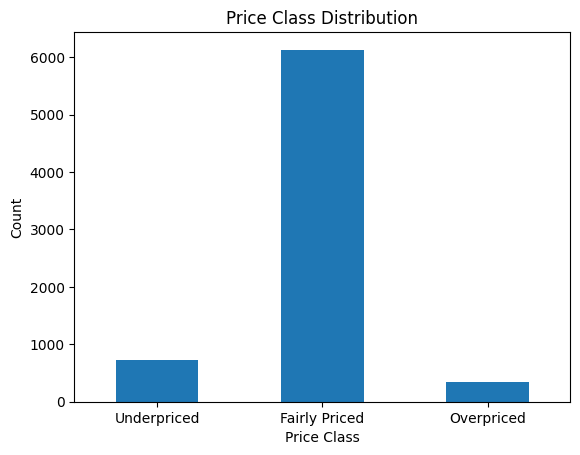

In [3]:
class_counts = df["price_class"].value_counts().sort_index()

print("Class distribution:")
print("0 Underpriced:", class_counts.get(0, 0))
print("1 Fairly Priced:", class_counts.get(1, 0))
print("2 Overpriced:", class_counts.get(2, 0))

class_counts.plot(kind="bar")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["Underpriced", "Fairly Priced", "Overpriced"],
    rotation=0
)
plt.title("Price Class Distribution")
plt.xlabel("Price Class")
plt.ylabel("Count")
plt.show()

## Step 3. Feature / Target 설정

`price_class`를 target 변수(y)로 설정한다.

차량의 제조사, 상태, 연식, 주행거리, MSRP 등 차량 정보를 feature(X)로 사용한다.

이후 머신러닝 분류 모델 학습을 위해 feature 데이터와 target 데이터를 분리한다.

In [4]:
# Target
y = df["price_class"]

# 사용 feature
feature_cols = [
    "manufacturer",
    "condition",
    "cylinders",
    "fuel",
    "odometer",
    "title_status",
    "transmission",
    "drive",
    "type",
    "paint_color",
    "vehicle_age",
    "estimate_msrp"
]

X = df[feature_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7192, 12)
y shape: (7192,)


## Step 4. 범주형 변수 인코딩

현재 feature에는 manufacturer, fuel, transmission 등 문자열 형태의 범주형 변수가 포함되어 있다.

머신러닝 모델은 문자열 데이터를 직접 처리할 수 없으므로 One-Hot Encoding을 사용하여 숫자 형태로 변환한다.

`pd.get_dummies()`를 사용하여 범주형 변수를 인코딩한다.

In [5]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print("Encoded X shape:", X_encoded.shape)
X_encoded.head()

Encoded X shape: (7192, 85)


,odometer,vehicle_age,estimate_msrp,manufacturer_alfa-romeo,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,manufacturer_chevrolet,manufacturer_chrysler,...,paint_color_brown,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow
0,72238.0,5.0,35290.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,59734.0,5.0,14000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,70760.0,4.0,51540.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,80146.0,10.0,33500.0,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,78554.0,6.0,19800.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


## Step 5. Train / Test 데이터 분할

분류 모델 성능 평가를 위해 데이터를 학습용(Train)과 테스트용(Test)으로 분리한다.

- Train : 80%
- Test : 20%

또한 클래스 비율 유지를 위해 stratify 옵션을 사용한다.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5753, 85)
Test shape: (1439, 85)


## Step 6. 분류 모델 생성

차량 가격 적정성 분류를 위해 다음 3가지 분류 모델을 사용한다.

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

각 모델의 성능을 비교하여 가장 우수한 모델을 선택한다.

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

## Step 7. Classification 모델 학습 및 평가

각 분류 모델을 학습한 후 테스트 데이터에 대해 예측을 수행한다.

성능 평가는 다음 지표를 사용한다.

- Accuracy
- Precision
- Recall
- F1-score

현재 데이터는 Fairly Priced 클래스가 많은 불균형 데이터이므로, Accuracy뿐만 아니라 F1-score도 함께 확인한다.

In [8]:
results = []

fitted_models = {}

for name, model in models.items():
    
    print("=" * 60)
    print(f"Model: {name}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })
    
    fitted_models[name] = model
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()

Model: Logistic Regression


c:\Users\semun\OneDrive\Desktop\Team project_DS\Craigslist-used-car-predictor\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy : 0.8520
Precision: 0.7795
Recall   : 0.8520
F1-score : 0.7978

Model: Decision Tree
Accuracy : 0.7818
Precision: 0.7770
Recall   : 0.7818
F1-score : 0.7793

Model: Random Forest
Accuracy : 0.8499
Precision: 0.7830
Recall   : 0.8499
F1-score : 0.7949



## Step 8. Classification 모델 성능 비교

모델별 성능을 표로 비교한다.

클래스 불균형이 존재하기 때문에 최종 모델 선택 시 Accuracy뿐 아니라 F1-score를 함께 고려한다.

In [9]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1-score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.851981,0.779507,0.851981,0.797775
2,Random Forest,0.849896,0.783023,0.849896,0.794901
1,Decision Tree,0.781793,0.777038,0.781793,0.779321


## Step 9. K-Fold Cross Validation

모델 성능이 특정 Train/Test 분할에만 의존하지 않는지 확인하기 위해 K-Fold Cross Validation을 수행한다.

여기서는 5-Fold Cross Validation을 사용한다.

평가 지표는 Accuracy를 사용한다.

In [10]:
cv_results = []

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring="accuracy"
    )
    
    cv_results.append({
        "Model": name,
        "CV Mean Accuracy": scores.mean(),
        "CV Std": scores.std()
    })
    
    print("=" * 60)
    print(f"Model: {name}")
    print("CV Scores:", scores)
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Std: {scores.std():.4f}")
    print()

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="CV Mean Accuracy",
    ascending=False
)

c:\Users\semun\OneDrive\Desktop\Team project_DS\Craigslist-used-car-predictor\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\semun\OneDrive\Desktop\Team project_DS\Craigslist-used-car-predictor\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You migh

Model: Logistic Regression
CV Scores: [0.85267547 0.85406532 0.85326843 0.85257302 0.8511822 ]
Mean Accuracy: 0.8528
Std: 0.0009

Model: Decision Tree
CV Scores: [0.78318277 0.78943711 0.78303199 0.79137691 0.78581363]
Mean Accuracy: 0.7866
Std: 0.0033

Model: Random Forest
CV Scores: [0.85267547 0.8561501  0.85605007 0.84909597 0.84909597]
Mean Accuracy: 0.8526
Std: 0.0031



,Model,CV Mean Accuracy,CV Std
0,Logistic Regression,0.852753,0.000948
2,Random Forest,0.852614,0.003133
1,Decision Tree,0.786568,0.003343


## Step 10. Confusion Matrix 분석

최종 선택된 Logistic Regression 모델에 대해 Confusion Matrix를 확인한다.

이를 통해 각 클래스(Underpriced, Fairly Priced, Overpriced)가 얼마나 정확하게 분류되었는지 확인한다.

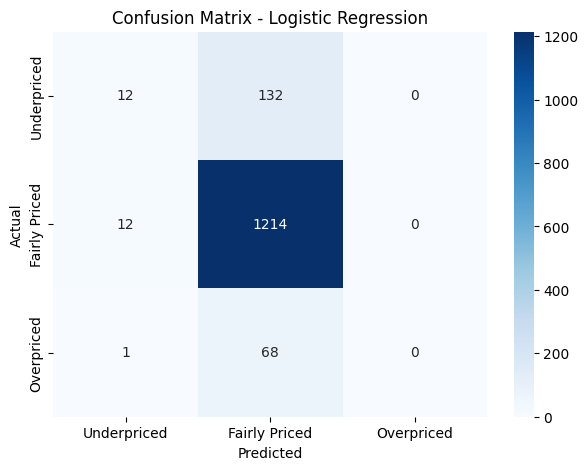

In [11]:
best_model = fitted_models["Logistic Regression"]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Underpriced", "Fairly Priced", "Overpriced"],
    yticklabels=["Underpriced", "Fairly Priced", "Overpriced"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Step 11. Conclusion

본 프로젝트에서는 중고차 가격 데이터를 기반으로 차량 가격 적정성을 분류하는 머신러닝 모델을 구축하였다.

Regression 단계에서 예측한 차량 적정 가격을 기반으로 price_class를 생성하였고, 이를 이용하여 Classification 모델을 학습하였다.

총 3개의 분류 모델(Logistic Regression, Decision Tree, Random Forest)을 비교한 결과, Logistic Regression 모델이 가장 우수한 성능을 보였다.

- Accuracy: 약 85%
- F1-score: 약 0.80

Cross Validation 결과에서도 안정적인 성능을 확인하였다.

하지만 데이터 불균형으로 인해 Underpriced 및 Overpriced 클래스 예측에는 한계가 존재하였다.

향후에는 데이터 균형 조정(SMOTE 등) 및 Hyperparameter Tuning을 통해 성능 개선이 가능할 것으로 보인다.